In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import os

In [3]:
df = pd.read_csv("dataset/Sample - Superstore.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
os.makedirs("charts", exist_ok=True)
os.makedirs("dashboard", exist_ok=True)
os.makedirs("sql_queries", exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [5]:
conn = sqlite3.connect("superstore.db")

df.to_sql("superstore", conn, if_exists="replace", index=False)

print("Database created successfully!")

Database created successfully!


In [6]:
query = """
SELECT
    "Product Name",
    SUM(Sales) AS Total_Sales
FROM superstore
GROUP BY "Product Name"
ORDER BY Total_Sales DESC
LIMIT 10
"""

top_products = pd.read_sql_query(query, conn)

top_products

,Product Name,Total_Sales
0,Canon imageCLASS 2200 Advanced Copier,61599.824
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
2,Cisco TelePresence System EX90 Videoconferenci...,22638.480
3,HON 5400 Series Task Chairs for Big and Tall,21870.576
4,GBC DocuBind TL300 Electric Binding System,19823.479
5,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
6,Hewlett Packard LaserJet 3310 Copier,18839.686
7,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
8,GBC DocuBind P400 Electric Binding System,17965.068
9,High Speed Automatic Electric Letter Opener,17030.312


In [8]:
top_products.to_csv(
    "sql_queries/top_products.csv",
    index=False
)

In [9]:
query = """
SELECT
    Region,
    SUM(Sales) AS Total_Sales
FROM superstore
GROUP BY Region
ORDER BY Total_Sales DESC
"""

region_sales = pd.read_sql_query(query, conn)

region_sales

,Region,Total_Sales
0,West,725457.8245
1,East,678781.2400
2,Central,501239.8908
3,South,391721.9050


In [10]:
region_sales.to_csv(
    "sql_queries/region_sales.csv",
    index=False
)

In [11]:
query = """
SELECT
    Category,
    SUM(Profit) AS Total_Profit
FROM superstore
GROUP BY Category
ORDER BY Total_Profit DESC
"""

category_profit = pd.read_sql_query(query, conn)

category_profit

,Category,Total_Profit
0,Technology,145454.9481
1,Office Supplies,122490.8008
2,Furniture,18451.2728


In [12]:
category_profit.to_csv(
    "sql_queries/category_profit.csv",
    index=False
)

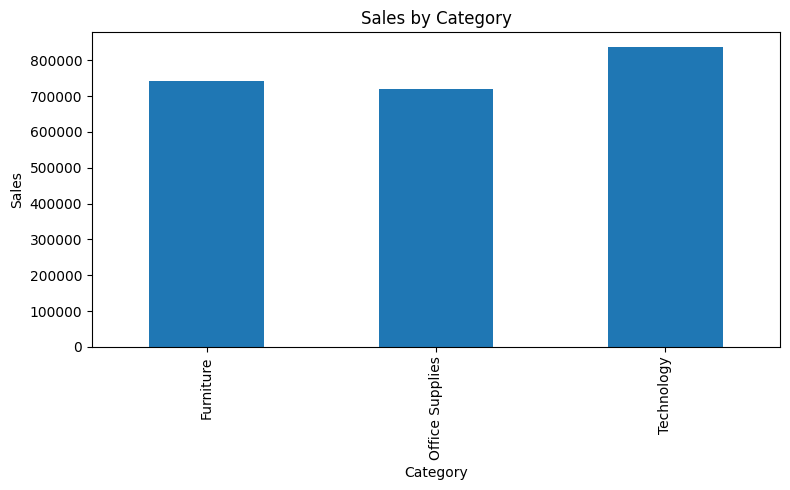

In [13]:
sales_category = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(8,5))
sales_category.plot(kind="bar")
plt.title("Sales by Category")
plt.ylabel("Sales")
plt.tight_layout()

plt.savefig("charts/sales_by_category.png")
plt.show()

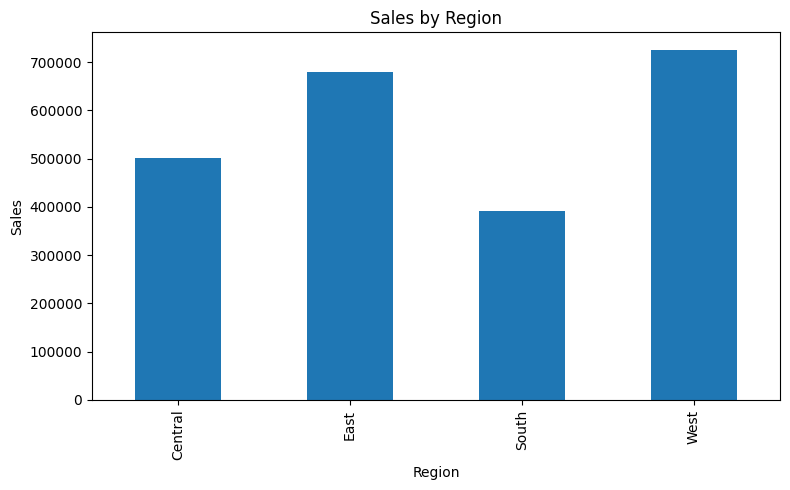

In [14]:
region = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(8,5))
region.plot(kind="bar")
plt.title("Sales by Region")
plt.ylabel("Sales")
plt.tight_layout()

plt.savefig("charts/sales_by_region.png")
plt.show()

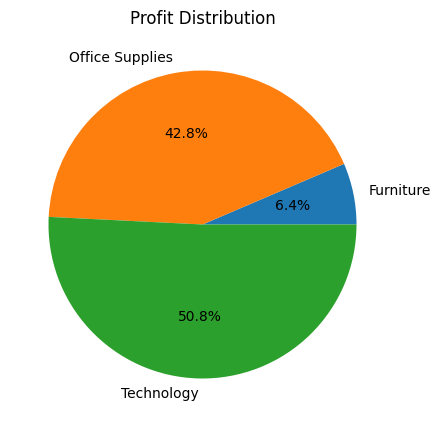

In [15]:
profit = df.groupby("Category")["Profit"].sum()

plt.figure(figsize=(8,5))
profit.plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")
plt.title("Profit Distribution")

plt.savefig("charts/profit_by_category.png")
plt.show()

In [19]:
html = """
<!DOCTYPE html>
<html>

<head>
<title>Superstore Sales Dashboard</title>

<style>

body{
    font-family: Arial, sans-serif;
    background: linear-gradient(135deg,#667eea,#764ba2);
    margin:0;
    padding:20px;
}

h1{
    text-align:center;
    color:white;
    margin-bottom:30px;
}

.container{
    display:grid;
    grid-template-columns:repeat(auto-fit,minmax(500px,1fr));
    gap:20px;
}

.card{
    background:white;
    border-radius:15px;
    padding:20px;
    box-shadow:0px 5px 15px rgba(0,0,0,0.3);
    transition:0.3s;
}

.card:hover{
    transform:scale(1.03);
}

.card h2{
    text-align:center;
    color:#333;
}

img{
    width:100%;
    border-radius:10px;
}

.footer{
    text-align:center;
    color:white;
    margin-top:30px;
    font-size:18px;
}

</style>
</head>

<body>

<h1>📊 Superstore Sales Dashboard</h1>

<div style="display:flex;justify-content:center;gap:20px;flex-wrap:wrap;margin-bottom:30px;">

    <div style="background:#00c853;color:white;padding:20px;border-radius:15px;width:220px;text-align:center;box-shadow:0px 5px 15px rgba(0,0,0,0.3);">
        <h2>Total Sales</h2>
        <h1>$2.30M</h1>
    </div>

    <div style="background:#2962ff;color:white;padding:20px;border-radius:15px;width:220px;text-align:center;box-shadow:0px 5px 15px rgba(0,0,0,0.3);">
        <h2>Total Profit</h2>
        <h1>$286K</h1>
    </div>

    <div style="background:#ff6d00;color:white;padding:20px;border-radius:15px;width:220px;text-align:center;box-shadow:0px 5px 15px rgba(0,0,0,0.3);">
        <h2>Total Orders</h2>
        <h1>5009</h1>
    </div>

</div>

<div class="container">
<div class="card">
<h2>Sales by Category</h2>
<img src="../charts/sales_by_category.png">
</div>

<div class="card">
<h2>Sales by Region</h2>
<img src="../charts/sales_by_region.png">
</div>

<div class="card">
<h2>Profit Distribution</h2>
<img src="../charts/profit_by_category.png">
</div>

</div>

<div class="footer">
Created using Python • SQL • Jupyter Notebook
</div>

</body>
</html>
"""

with open("dashboard/dashboard.html", "w", encoding="utf-8") as f:
    f.write(html)

print("Colorful dashboard saved successfully!")

Colorful dashboard saved successfully!


In [18]:
total_sales = round(df["Sales"].sum(),2)
total_profit = round(df["Profit"].sum(),2)
total_orders = df["Order ID"].nunique()